# Yahoo finance

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd 
import yfinance as yf
import os.path

In [3]:
symbol = 'SPY'
ticker = yf.Ticker(symbol)

In [4]:
pd.Series(ticker.info).head()

longBusinessSummary    The trust seeks to achieve its investment obje...
companyOfficers                                                       []
executiveTeam                                                         []
maxAge                                                             86400
priceHint                                                              2
dtype: object

### Get market data

In [5]:
data = ticker.history(period="5d",
                      interval="1m",
                      start=None,
                      end = None,
                      actions = True, 
                      auto_adjust = True,
                      back_adjust = False)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1756 entries, 2025-12-19 09:30:00-05:00 to 2025-12-26 15:59:00-05:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           1756 non-null   float64
 1   High           1756 non-null   float64
 2   Low            1756 non-null   float64
 3   Close          1756 non-null   float64
 4   Volume         1756 non-null   int64  
 5   Dividends      1756 non-null   float64
 6   Stock Splits   1756 non-null   float64
 7   Capital Gains  1756 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 123.5 KB


In [6]:
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Datetime,,,,,,,,
2025-12-19 09:30:00-05:00,677.000000,677.210022,677.000000,677.114990,1932696,1.993,0.0,0.0
2025-12-19 09:31:00-05:00,677.179993,677.761292,677.140015,677.659973,681154,0.000,0.0,0.0
2025-12-19 09:32:00-05:00,677.669983,678.080017,677.529785,677.830017,608338,0.000,0.0,0.0
2025-12-19 09:33:00-05:00,677.859985,678.200012,677.719971,677.820007,414235,0.000,0.0,0.0
2025-12-19 09:34:00-05:00,677.840027,678.229980,677.659973,678.219910,622281,0.000,0.0,0.0


<Axes: xlabel='Datetime'>

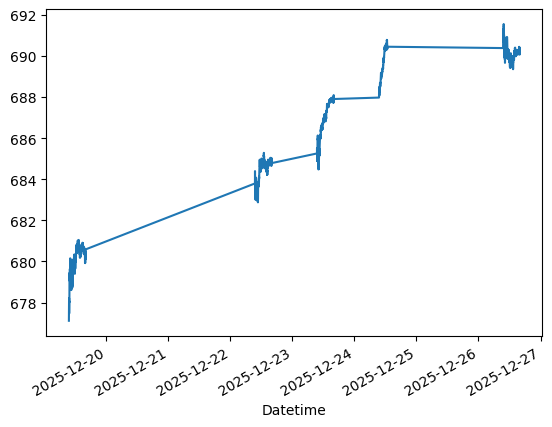

In [7]:
data.Close.plot()

In [8]:
data = ticker.history(period = "20y")

In [9]:
data.to_csv(os.path.join('data', 'stocks.csv'))

In [ ]:
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-06-26 00:00:00-04:00,39.771690,39.821230,39.543800,39.543800,36700,0.0,0.0,0.0
2025-06-27 00:00:00-04:00,39.781598,39.999576,39.781598,39.879688,11300,0.0,0.0,0.0
2025-06-30 00:00:00-04:00,40.078845,40.197743,39.930220,40.102623,28700,0.0,0.0,0.0
2025-07-01 00:00:00-04:00,39.991653,41.025082,39.950039,40.023361,11300,0.0,0.0,0.0
2025-07-02 00:00:00-04:00,39.941125,39.989675,39.870777,39.880684,50300,0.0,0.0,0.0


<Axes: xlabel='Date'>

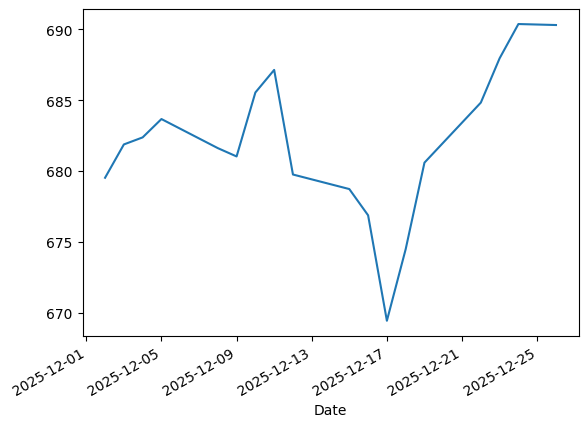

In [11]:
data.Close[data.index > "2025-12"].plot()

### View company actions

In [12]:
ticker.actions

TypeError: 'NoneType' object is not subscriptable

In [ ]:
ticker.dividends

Date
2025-09-24 00:00:00-04:00    0.145
2025-12-24 00:00:00-05:00    0.242
Name: Dividends, dtype: float64

In [ ]:
ticker.splits

Series([], Name: Stock Splits, dtype: float64)

# Annual and Quaterly financial statements summary

In [ ]:
ticker.financials

""


In [ ]:
ticker.quarterly_financials

""


In [ ]:
ticker.balance_sheet

""


In [ ]:
ticker.quarterly_balance_sheet

""


In [ ]:
ticker.cashflow

""


In [ ]:
ticker.quarterly_cashflow

""


In [ ]:
ticker.earnings

c:\Users\Marti\OneDrive\Escritorio\Python projects\AlgoTrading\libraries\Lib\site-packages\yfinance\scrapers\fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)


In [ ]:
ticker.quarterly_earnings

In [ ]:
ticker.sustainability

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: FB"}}}


""


### Analyst recommendations

In [ ]:
ticker.recommendations.info()

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: FB"}}}


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [ ]:
ticker.calendar

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: FB"}}}


{}

### Options expiration dates

In [ ]:
ticker.options

('2026-02-21',)

In [ ]:
expiration = ticker.options[0]
options = ticker.option_chain(expiration)
options.calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   contractSymbol     0 non-null      float64            
 1   lastTradeDate      0 non-null      datetime64[ns, UTC]
 2   strike             0 non-null      float64            
 3   lastPrice          0 non-null      float64            
 4   bid                0 non-null      float64            
 5   ask                0 non-null      float64            
 6   change             0 non-null      float64            
 7   percentChange      0 non-null      float64            
 8   volume             0 non-null      float64            
 9   openInterest       0 non-null      float64            
 10  impliedVolatility  0 non-null      float64            
 11  inTheMoney         0 non-null      float64            
 12  contractSize       0 non-null      float64            
 13  cu

In [ ]:
options.calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency


# Multiple indexes

In [13]:
data = yf.download(
        tickers = "SPY AAPL MSFT", # list or string

        # use "period" instead of start/end
        # valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (optional, default is '1mo')
        period = "20y",

        # fetch data by interval (including intraday if period < 60 days)
        # valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (optional, default is '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (optional, default is 'column')
        group_by = 'ticker',

        # adjust all OHLC automatically
        # (optional, default is False)
        auto_adjust = True,

        # download pre/post regular market hours data
        # (optional, default is False)
        prepost = True,

        # use threads for mass downloading? (True/False/Integer)
        # (optional, default is True)
        threads = True,

    )

[*********************100%***********************]  3 of 3 completed


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5032 entries, 2005-12-27 to 2025-12-26
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (MSFT, Open)    5032 non-null   float64
 1   (MSFT, High)    5032 non-null   float64
 2   (MSFT, Low)     5032 non-null   float64
 3   (MSFT, Close)   5032 non-null   float64
 4   (MSFT, Volume)  5032 non-null   int64  
 5   (AAPL, Open)    5032 non-null   float64
 6   (AAPL, High)    5032 non-null   float64
 7   (AAPL, Low)     5032 non-null   float64
 8   (AAPL, Close)   5032 non-null   float64
 9   (AAPL, Volume)  5032 non-null   int64  
 10  (SPY, Open)     5032 non-null   float64
 11  (SPY, High)     5032 non-null   float64
 12  (SPY, Low)      5032 non-null   float64
 13  (SPY, Close)    5032 non-null   float64
 14  (SPY, Volume)   5032 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 629.0 KB


In [15]:
data.head()

Ticker           MSFT                                                 AAPL  \
Price            Open       High        Low      Close    Volume      Open   
Date                                                                         
2005-12-27  18.603493  18.722031  18.443119  18.450090  37819000  2.219337   
2005-12-28  18.484958  18.589550  18.373393  18.401283  35444400  2.233433   
2005-12-29  18.415221  18.477977  18.310629  18.317602  34495500  2.212739   
2005-12-30  18.233932  18.345498  18.199069  18.233932  49044600  2.126665   
2006-01-03  18.303657  18.826619  18.199065  18.715054  79973000  2.170752   

Ticker                                                     SPY             \
Price           High       Low     Close     Volume       Open       High   
Date                                                                        
2005-12-27  2.254726  2.217837  2.226235  590590000  87.642754  87.704885   
2005-12-28  2.242130  2.198943  2.206441  398115200  86.800545  86.973124   
2005-12-29  2.213939  2.141960  2.142860  490025200  86.786751  86.952426   
2005-12-30  2.172252  2.109570  2.156057  624262800  86.151647  86.331126   
2006-01-03  2.241830  2.166853  2.241830  807234400  86.420873  87.670347   

Ticker                                      
Price             Low      Close    Volume  
Date                                        
2005-12-27  86.552050  86.614182  44499500  
2005-12-28  86.634870  86.807449  30764300  
2005-12-29  86.331138  86.420883  32788900  
2005-12-30  85.847905  85.951454  44645600  
2006-01-03  85.868617  87.463249  73256700

In [18]:
data.to_csv(os.path.join('data', 'stocks.csv'))